# 1. SETUP & IMPORTS

In [ ]:
import os, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True


# **2. DATASET**

In [ ]:
class RAVDESSDataset(Dataset):
    def __init__(self, base_path):
        self.audio_path = os.path.join(base_path, "audio")
        self.video_path = os.path.join(base_path, "frames")

        self.audio_files = sorted(os.listdir(self.audio_path))
        self.video_files = sorted(os.listdir(self.video_path))

        labels_dict = np.load(
            os.path.join(base_path, "labels.npy"),
            allow_pickle=True
        ).item()

        self.labels = []
        for file in self.audio_files:
            key = file.replace(".npy", "")
            self.labels.append(labels_dict[key])

        self.labels = np.array(self.labels, dtype=np.int64)

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, idx):
        audio = np.load(os.path.join(self.audio_path, self.audio_files[idx]), allow_pickle=True)
        video = np.load(os.path.join(self.video_path, self.video_files[idx]), allow_pickle=True)

        audio = audio.T  # (100, 40)

        return (
            torch.tensor(audio, dtype=torch.float32),
            torch.tensor(video, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# **3. MODELS**

**🔊 Audio Model**

In [ ]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=40, hidden_dim=128):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, 3, padding=1)
        self.conv2 = nn.Conv1d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)
        self.lstm = nn.LSTM(128, hidden_dim, batch_first=True)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        _, (hn, _) = self.lstm(x)
        return hn[-1]

**🎥 Video Model (T4 optimized)**

In [ ]:
import torchvision.models as models

class VideoModel(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        resnet = models.resnet18(pretrained=True)

        # 🔥 freeze
        for p in resnet.parameters():
            p.requires_grad = False

        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        self.bilstm = nn.LSTM(512, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        B, T, H, W, C = x.shape
        x = x.permute(0,1,4,2,3).reshape(B*T, C, H, W)

        with torch.no_grad():  # 🔥 T4 optimization
            features = self.feature_extractor(x)

        features = features.view(B, T, 512)

        _, (hn, _) = self.bilstm(features)
        h = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.dropout(h)


**🔥 Attention Fusion**

In [ ]:
class AttentionFusion(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim*2, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, a, v):
        combined = torch.cat((a, v), dim=1)
        w = F.softmax(self.attn(combined), dim=1)

        wa = w[:,0].unsqueeze(1)
        wv = w[:,1].unsqueeze(1)

        fused = wa*a + wv*v
        return fused, w

**🔥 Final Model**

In [ ]:
class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.audio = AudioModel()
        self.video = VideoModel()
        self.attn = AttentionFusion(128)

        self.fc1 = nn.Linear(128, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 6)

    def forward(self, audio, video):
        a = self.audio(audio)
        v = self.video(video)

        fused, weights = self.attn(a, v)

        x = F.relu(self.fc1(fused))
        x = self.dropout(x)

        return self.fc2(x), weights

# **4. DATA LOADER**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dataset = RAVDESSDataset("/content/drive/MyDrive/RAVDESS_processed")

print(len(dataset))          # should work
print(dataset[0][0].shape)  # audio shape
print(dataset[0][1].shape)  # video shape
print(dataset[0][2])        # label

2112
torch.Size([100, 40])
torch.Size([20, 112, 112, 3])
tensor(0)


In [ ]:
labels = np.load("/content/drive/MyDrive/RAVDESS_processed/labels.npy", allow_pickle=True)

print(type(labels))
print(labels.shape)
print(labels)

<class 'numpy.ndarray'>
()
{'01-01-01-01-01-01-01': 0, '01-01-01-01-01-02-01': 0, '01-01-01-01-02-01-01': 0, '01-01-01-01-02-02-01': 0, '01-01-02-01-01-01-01': 0, '01-01-02-01-01-02-01': 0, '01-01-02-01-02-01-01': 0, '01-01-02-01-02-02-01': 0, '01-01-02-02-01-01-01': 0, '01-01-02-02-01-02-01': 0, '01-01-02-02-02-01-01': 0, '01-01-02-02-02-02-01': 0, '01-01-03-01-01-01-01': 1, '01-01-03-01-01-02-01': 1, '01-01-03-01-02-01-01': 1, '01-01-03-01-02-02-01': 1, '01-01-03-02-01-01-01': 1, '01-01-03-02-01-02-01': 1, '01-01-03-02-02-01-01': 1, '01-01-03-02-02-02-01': 1, '01-01-04-01-01-01-01': 2, '01-01-04-01-01-02-01': 2, '01-01-04-01-02-01-01': 2, '01-01-04-01-02-02-01': 2, '01-01-04-02-01-01-01': 2, '01-01-04-02-01-02-01': 2, '01-01-04-02-02-01-01': 2, '01-01-04-02-02-02-01': 2, '01-01-05-01-01-01-01': 3, '01-01-05-01-01-02-01': 3, '01-01-05-01-02-01-01': 3, '01-01-05-01-02-02-01': 3, '01-01-05-02-01-01-01': 3, '01-01-05-02-01-02-01': 3, '01-01-05-02-02-01-01': 3, '01-01-05-02-02-02-01': 3, 

In [ ]:
from torch.utils.data import random_split

In [ ]:
dataset = RAVDESSDataset("/content/drive/MyDrive/RAVDESS_processed")

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [ ]:
print(len(train_dataset))
print(len(val_dataset))

1689
423


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,   # ❗ no shuffle in validation
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# **5. TRAIN SETUP**

In [ ]:
model = FusionModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_10405/2692201474.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# **6. CHECKPOINT + LOGGING**

In [ ]:
save_path = "/content/drive/MyDrive/training_log.json"
ckpt_path = "/content/drive/MyDrive/model_checkpoint.pth"

history = []

if os.path.exists(save_path):
    with open(save_path, "r") as f:
        history = json.load(f)

start_epoch = 0
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["opt"])
    start_epoch = ckpt["epoch"] + 1

In [ ]:
os.listdir("/content")
os.listdir("/content/drive/MyDrive")

['Classroom',
 'Mihir',
 'College',
 'E&PC (Reading material) Odd Sem 2023-24',
 'Assignment 4.pdf',
 '12.pdf',
 'Colab Notebooks',
 '1.html',
 'A.png',
 'index (1).html',
 'h.jpg',
 'Copy of Class_Object_Consturctor.cpp',
 'Google AI Studio',
 'IMG_20250708_182758.jpg',
 'Spotify',
 '.ipynb_checkpoints',
 'autoCV.pdf',
 'MihirVilasHajareResume (2).pdf',
 'My resume',
 'eip form (1).pdf',
 'eip form.pdf',
 'cv (1).pdf',
 'Sem5_Gradesheet.jpeg',
 '3.jpeg',
 '3_merged.pdf',
 'eip.pdf',
 'Document from Mihir',
 'RAVDESS',
 'RAVDESS_processed']

In [ ]:
import os
os.listdir("/content/drive/MyDrive")

['Classroom',
 'Mihir',
 'College',
 'E&PC (Reading material) Odd Sem 2023-24',
 'Assignment 4.pdf',
 '12.pdf',
 'Colab Notebooks',
 '1.html',
 'A.png',
 'index (1).html',
 'h.jpg',
 'Copy of Class_Object_Consturctor.cpp',
 'Google AI Studio',
 'IMG_20250708_182758.jpg',
 'Spotify',
 '.ipynb_checkpoints',
 'autoCV.pdf',
 'MihirVilasHajareResume (2).pdf',
 'My resume',
 'eip form (1).pdf',
 'eip form.pdf',
 'cv (1).pdf',
 'Sem5_Gradesheet.jpeg',
 '3.jpeg',
 '3_merged.pdf',
 'eip.pdf',
 'Document from Mihir',
 'RAVDESS',
 'RAVDESS_processed',
 'best_model.pth',
 'training_log.json',
 'model_checkpoint.pth']

# **7. TRAIN LOOP**

In [ ]:
from tqdm import tqdm

# 🔥 Initialize BEFORE training loop (IMPORTANT)
best_f1 = 0

for epoch in range(start_epoch, 20):

    model.train()
    all_preds, all_labels = [], []
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=True)

    for i, (audio, video, labels) in enumerate(pbar):

        audio, video, labels = audio.to(device), video.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs, _ = model(audio, video)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({
            "batch": f"{i+1}/{len(train_loader)}",
            "loss": f"{loss.item():.4f}"
        })

    # =========================
    # 🔷 METRICS
    # =========================
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    log = {
        "epoch": epoch,
        "loss": total_loss / len(train_loader),
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    history.append(log)

    # =========================
    # 🔥 BEST MODEL SAVE (ADD HERE)
    # =========================
    if f1 > best_f1:
        best_f1 = f1

        torch.save({
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "f1": f1
        }, "/content/drive/MyDrive/best_model.pth")

        print(f"🔥 Best model saved at epoch {epoch} with F1: {f1:.4f}")

    # =========================
    # 🔷 SAVE LOG
    # =========================
    with open(save_path, "w") as f:
        json.dump(history, f, indent=4)

    # =========================
    # 🔷 CHECKPOINT SAVE
    # =========================
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "opt": optimizer.state_dict()
    }, ckpt_path)

    print(f"\n✅ Epoch {epoch} Completed:", log)

Epoch 0:   0%|          | 0/212 [00:00<?, ?it/s]/tmp/ipykernel_10405/3649049753.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 0: 100%|██████████| 212/212 [00:19<00:00, 10.81it/s, batch=212/212, loss=1.8770]


🔥 Best model saved at epoch 0 with F1: 0.3063

✅ Epoch 0 Completed: {'epoch': 0, 'loss': 1.504251480102539, 'accuracy': 0.35227945529899346, 'precision': 0.3260137620353655, 'recall': 0.35227945529899346, 'f1': 0.30631894687800665}


Epoch 1:   0%|          | 0/212 [00:00<?, ?it/s]/tmp/ipykernel_10405/3649049753.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 212/212 [00:15<00:00, 13.60it/s, batch=212/212, loss=1.9404]


🔥 Best model saved at epoch 1 with F1: 0.4579

✅ Epoch 1 Completed: {'epoch': 1, 'loss': 1.2241569869923141, 'accuracy': 0.4843102427471877, 'precision': 0.4567650299523107, 'recall': 0.4843102427471877, 'f1': 0.45790053818740156}


Epoch 2:   0%|          | 0/212 [00:00<?, ?it/s]/tmp/ipykernel_10405/3649049753.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 2: 100%|██████████| 212/212 [00:16<00:00, 12.76it/s, batch=212/212, loss=3.5195]


...


✅ Epoch 17 Completed: {'epoch': 17, 'loss': 0.32055484447276816, 'accuracy': 0.8851391355831854, 'precision': 0.8845873075508482, 'recall': 0.8851391355831854, 'f1': 0.8846676215682933}


Epoch 18:   0%|          | 0/212 [00:00<?, ?it/s]/tmp/ipykernel_10405/3649049753.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 18: 100%|██████████| 212/212 [00:16<00:00, 13.14it/s, batch=212/212, loss=2.6250]



✅ Epoch 18 Completed: {'epoch': 18, 'loss': 0.30988156647895865, 'accuracy': 0.8880994671403197, 'precision': 0.8878015175971125, 'recall': 0.8880994671403197, 'f1': 0.8878787392440523}


Epoch 19:   0%|          | 0/212 [00:00<?, ?it/s]/tmp/ipykernel_10405/3649049753.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 19: 100%|██████████| 212/212 [00:15<00:00, 13.42it/s, batch=212/212, loss=2.0508]


🔥 Best model saved at epoch 19 with F1: 0.9218

✅ Epoch 19 Completed: {'epoch': 19, 'loss': 0.24511594845438903, 'accuracy': 0.9218472468916519, 'precision': 0.921790595577634, 'recall': 0.9218472468916519, 'f1': 0.921754040288194}


In [ ]:
# =========================
# 🔷 LOAD BEST MODEL
# =========================
checkpoint = torch.load("/content/drive/MyDrive/best_model.pth")

model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()

FusionModel(
  (audio): AudioModel(
    (conv1): Conv1d(40, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (dropout): Dropout(p=0.3, inplace=False)
    (lstm): LSTM(128, 128, batch_first=True)
  )
  (video): VideoModel(
    (feature_extractor): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
  

In [ ]:
# =========================
# 🔷 EVALUATION FUNCTION
# =========================
def evaluate_model(model, dataloader):

    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for audio, video, labels in dataloader:

            audio = audio.to(device)
            video = video.to(device)
            labels = labels.to(device)

            outputs, _ = model(audio, video)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return acc, precision, recall, f1, all_labels, all_preds

In [ ]:
# =========================
# 🔷 RUN EVALUATION
# =========================
acc, precision, recall, f1, labels, preds = evaluate_model(model, val_loader)

print("\n📊 FINAL EVALUATION:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


📊 FINAL EVALUATION:
Accuracy : 0.8983
Precision: 0.9058
Recall   : 0.8983
F1 Score : 0.9000


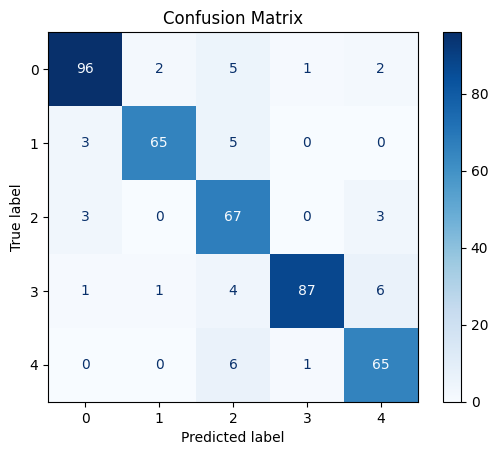

In [ ]:
# =========================
# 🔷 CONFUSION MATRIX
# =========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.savefig("/content/drive/MyDrive/confusion_matrix.png")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.pth'):
            print(os.path.join(root, file))

/content/drive/MyDrive/best_model.pth
/content/drive/MyDrive/model_checkpoint.pth


In [ ]:
import torch

model = torch.load('/content/drive/MyDrive/best_model.pth')
log = torch.load('/content/drive/MyDrive/model_checkpoint.pth')

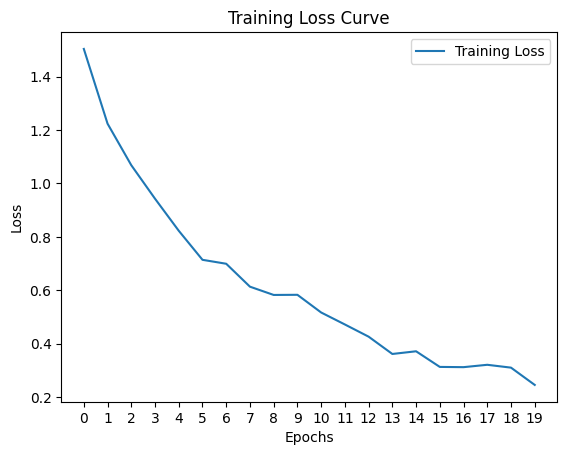

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(len(loss)))  # ensures integers

plt.figure()
plt.plot(epochs, loss, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

# Force integer ticks
plt.xticks(epochs)

plt.legend()
plt.show()

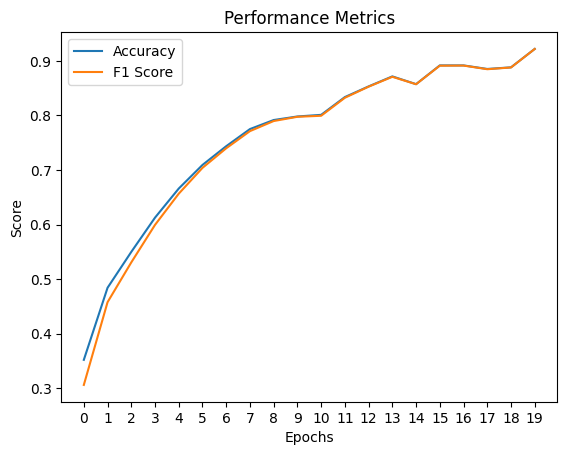

In [ ]:
plt.figure()
plt.plot(epochs, accuracy, label="Accuracy")
plt.plot(epochs, f1, label="F1 Score")

plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Performance Metrics")

# Force integer ticks
plt.xticks(epochs)

plt.legend()
plt.show()

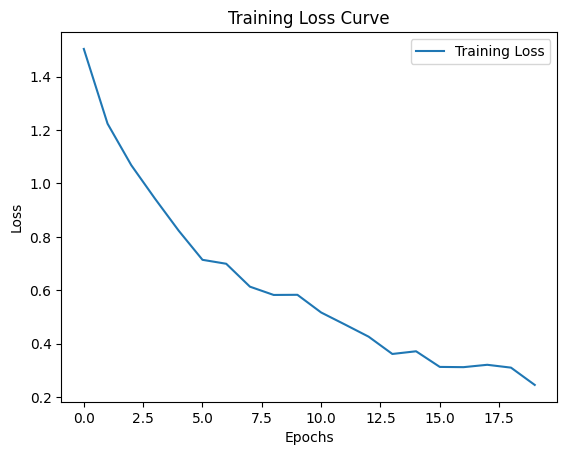

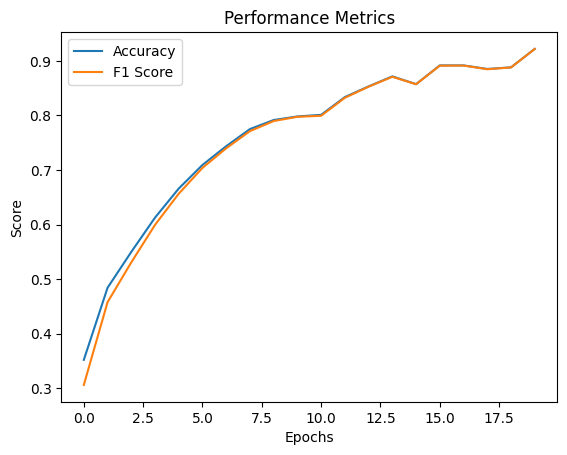

In [ ]:
import json
import matplotlib.pyplot as plt

# Load log
with open("/content/drive/MyDrive/training_log.json") as f:
    logs = json.load(f)

epochs = [x["epoch"] for x in logs]
loss = [x["loss"] for x in logs]
accuracy = [x["accuracy"] for x in logs]
precision = [x["precision"] for x in logs]
recall = [x["recall"] for x in logs]
f1 = [x["f1"] for x in logs]

# Loss Plot
plt.figure()
plt.plot(epochs, loss, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

# Accuracy Plot
plt.figure()
plt.plot(epochs, accuracy, label="Accuracy")
plt.plot(epochs, f1, label="F1 Score")
plt.xlabel("Epochs")
plt.ylabel("Score")
plt.title("Performance Metrics")
plt.legend()
plt.show()